In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
# display() sa pouziva pre spravne zobrazenie rovnic
from IPython.display import display, Latex


## Definice symbolu

In [2]:
# poloha, cas, gravitacni zrychleni, hmotnost
x, y, t, g, m = sp.symbols('x y t g m', positive=True)
# pocatecni rychlosti
v0x, v0y = sp.symbols('v_{0x} v_{0y}', positive=True)
# alternativne pocatecni rychlost a uhel
v0, alpha = sp.symbols('v_0 alpha', positive=True)

## Rychlosti a polohy v case t

In [3]:
vx = v0x
vy = v0y - g*t

x = sp.integrate(vx, t)
y = sp.integrate(vy, t)

print("Poloha v ose x:")
display(x)

print("Poloha v ose y:")
display(y)

Poloha v ose x:


t*v_{0x}

Poloha v ose y:


-g*t**2/2 + t*v_{0y}

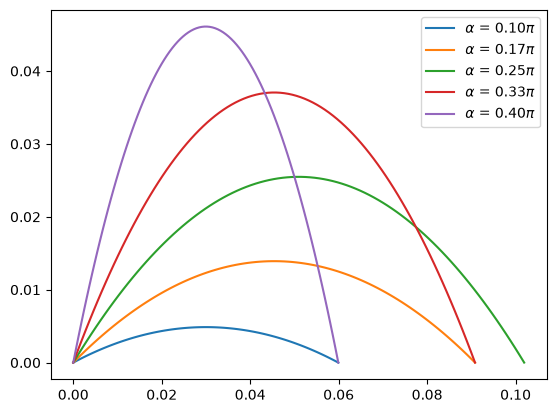

In [17]:
y_func = sp.lambdify((t, v0, alpha), y.subs({v0x: v0*sp.cos(alpha), v0y: v0*sp.sin(alpha), g: 9.81}))
x_func = sp.lambdify((t, v0, alpha), x.subs({v0x: v0*sp.cos(alpha), v0y: v0*sp.sin(alpha), g: 9.81}))

_v0 = 1
for _alpha in np.linspace(np.pi/10, np.pi/2 - np.pi/10, 5):
    ts = np.linspace(0, 2*_v0*np.sin(_alpha)/9.81, 100)
    xs = x_func(ts, _v0, _alpha)
    ys = y_func(ts, _v0, _alpha)
    plt.plot(xs, ys, label=f"$\\alpha$ = {_alpha/np.pi:0.2f}$\\pi$")

plt.legend()

## Maximálna výška a vzdialenosť dopadu

Maximálnu výšku získame z podmienky $$ v_y = \frac{dy}{dt} = 0, $$ z ktorej najprv určíme čas $t_{max}$ a dosadením do vzťahu vyššie $$ y_{max} = y(t_{max}) $$

In [ ]:
derivace = sp.diff(y, t)
print("Derivace y podle t:")
display(derivace)

# sp.solve() riesi rovnici derivace = 0, t.j. najde cas, kdy je rychlost v ose y nulova (vrchol paraboly)
t_max = sp.solve(derivace, t)[0]

display(Latex("$t_{max}$ = "), t_max)

y_max = y.subs(t, t_max)
display(Latex("$y_{max}$ = "), y_max)

Derivace y podle t:


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Trajektória je symetrická voči maximu, čas dopadu je jednoducho $t_{dopad} = 2t_{max}$ a bod dopadu je $$ \int_0^{2t_{max}}v_x(t) dt = 2v_{0x} t_{max} $$

In [ ]:
dopad = 2*v0x*t_max
display(Latex("$x_{dopad}$ = "), dopad)

<IPython.core.display.Latex object>

## Celková trajektória

Veľkosť rýchlosti je $$ v = \sqrt{v_x^2 + v_y^2}, $$ a celková trajektória $$ s_{total} = \int_0^{t_{dopad}} v d t $$

<IPython.core.display.Latex object>

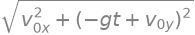

In [ ]:
v = sp.sqrt(vx**2 + vy**2)
display(Latex("$v$ = "), v)

<IPython.core.display.Latex object>

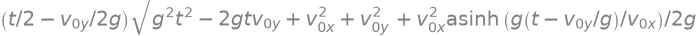

<IPython.core.display.Latex object>

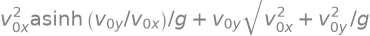

In [ ]:
_s = v.integrate(t)
display(Latex("Integrace rychlosti podle času $S(t) [ + C]$:"), _s)

draha = _s.subs(t, 2*t_max) - _s.subs(t, 0)
display(Latex("$s = S(2t_{max}) - S(0) $ = "), draha)

Ak re-parametrizujeme pomocou $v_0$ a uhlu $\alpha$:

In [ ]:
draha.subs({v0x: v0*sp.cos(alpha), v0y: v0*sp.sin(alpha)}).simplify()

Ktorý je možno ešte upraviť pomocou vzťahu $$ \mathrm{asinh}(x) = \ln(x + \sqrt{x^2 + 1}),$$ na (ak je $\cos\alpha > 0$)

$$ s = \frac{v_0^2}{g}\left[\sin\alpha + \cos^2\alpha\ln\left(\frac{1 + \sin\alpha}{\cos\alpha}\right) \right] $$